In [256]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def liter_per_minute_to_kg_per_s(lpm):
    """Convert flow rate from liters per minute to kg per second."""
    return (lpm * 1e-3) / 60.0 * 1000.0  # assuming water density ~1000 kg/m^3

Mass of each cell: 0.01 kg


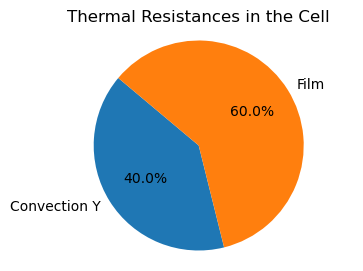

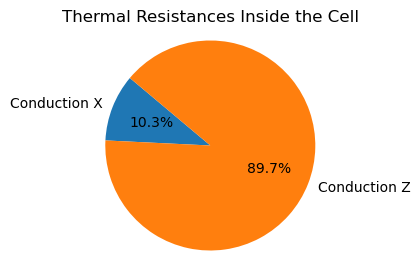

In [ ]:
# --- Constants ---
length = 0.270  # cell length in x [m]
height = 0.106  # cell height in z [m]
thickness = 0.0248  # cell thickness in y [m]
s_film = 1e-3  # film thickness [m] (0.1 mm)
volume = length * height * thickness  # cell volume [m^3]

# Discretization parameters
nx = 15 # discretization in x
nz = 2  # discretization in z-->!!!!!!!!DO NOT CHANGE THIS VALUE, IT IS A 1D SIMPLIFICATION
ny = 5  # discretization in y (1D simplification, use 1 for now)
dx = length / nx
dz = height / nz
dy = thickness / ny
dV = dx * dy * dz  # volume of each cell [m^3]

# Coolant properties
cp_fluid = 4186  # water [J/kg·K]
flow_rate = liter_per_minute_to_kg_per_s(0.29)  # flow rate [kg/s] (1 L/min)

# Boundary and initial conditions
T_init = 25  # Initial temperature [C]
T_fluid_in = 25  # Coolant inlet temperature [C]
h_conv = 300.0  # Convective heat transfer coefficient [W/m^2·K]

# Material properties
k_cell_x = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_cell_z = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_cell_y = 1.0          # thermal conductivity of cell in the plane y-z [W/m·K]
k_film = 0.2           # thermal conductivity of film [W/m·K] 

rho_cell = 2700.0    # density [kg/m^3] (Close to bulk Aluminum)
m_cell = rho_cell * dV  # mass of each cell [kg]
print(f"Mass of each cell: {m_cell:.2f} kg")
cp_cell = 897.0      # specific heat [J/kg·K] (Close to bulk Aluminum)
#alpha = k_cell_x / (rho_cell * cp_cell)  # thermal conductivity [m^2/s]

Rth_cond_x = dx / (k_cell_x*dz*dy)  # thermal resistance in x direction [K/W]
Rth_cond_z = dz / (k_cell_z*dx*dy)  # thermal resistance in x direction [K/W]
Rth_cond_y = dy / (k_cell_y*dx*dz)  # thermal resistance in y direction [K/W]
Rth_conv_y = 1/(h_conv * dx * dz)  # thermal resistance in y direction [K/W]
Rth_film = s_film/(k_film * dz * dx)  # thermal resistance of film [K/W]

#Pie chart of the resistances
resistances_y = {
    'Convection Y': Rth_conv_y,
    'Film': Rth_film
}
plt.figure(figsize=(4, 3))
plt.pie(resistances_y.values(), labels=resistances_y.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Thermal Resistances in the Cell')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

resistances_inside = {
    'Conduction X': Rth_cond_x,
    'Conduction Z': Rth_cond_z
}

plt.figure(figsize=(4, 3))
plt.pie(resistances_inside.values(), labels=resistances_inside.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Thermal Resistances Inside the Cell')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [258]:
# Time setup
dt = 5  # time step [s]
t_end = 10000  # total time [s]
nt = int(t_end / dt)


Q_tot = 60 # Total heat generation [W]
q_gen = Q_tot/volume # Heat generation [W/m^3]
print(f"Heat generation per unit volume: {q_gen:.2f} W/m^3")

# Cross-sectional area for convection (1D simplification)
A_conv = dz * dx  # 1m depth assumed

# --- Initialize temperature field ---
T = np.ones([nx, ny, nz]) * T_init
# --- Functions ---

def convection_loss(T_cell, T_fluid):
    q_conv = (T_cell - T_fluid)/(Rth_conv_y + Rth_film)
    return  q_conv


def update_fluid_temp(T_fluid, q_conv, flow_rate, cp_fluid):
    # m_dot * cp * dT = q_conv  => dT = q_conv / (m_dot * cp)
    m_dot = flow_rate  # [kg/s]
    dT_fluid = q_conv / (m_dot * cp_fluid)

    return T_fluid + dT_fluid


# --- Temperature Field Initialization ---
T = np.ones((nx, ny, nz)) * T_init  # 3D temperature grid
T_hist = np.zeros((nt, nx, ny, nz))  # Temperature history

# --- Fluid Temperature Tracking (z = 0 forward, z = 1 backward) ---
T_fluid_z0 = np.ones(nx) * T_fluid_in
T_fluid_z1 = np.ones(nx) * T_fluid_in
t_hist_fluid_z0 = np.zeros((nt, nx))
t_hist_fluid_z1 = np.zeros((nt, nx))


# --- Time Loop ---
for t in range(nt):
    T_new = T.copy()
    Q_cond = np.zeros_like(T)

    # --- Conduction: X Direction ---
    for i in range(nx - 1):
        for j in range(ny):
            for k in range(nz):
                dT = T[i + 1, j, k] - T[i, j, k]
                q = dT / Rth_cond_x
                Q_cond[i, j, k] += q
                Q_cond[i + 1, j, k] -= q

    # --- Conduction: Y Direction ---
    for j in range(ny - 1):
        for i in range(nx):
            for k in range(nz):
                dT = T[i, j + 1, k] - T[i, j, k]
                q = dT / Rth_cond_y
                Q_cond[i, j, k] += q
                Q_cond[i, j + 1, k] -= q

    # --- Conduction: Z Direction ---
    for k in range(nz - 1):
        for i in range(nx):
            for j in range(ny):
                dT = T[i, j, k + 1] - T[i, j, k]
                q = dT / Rth_cond_z
                Q_cond[i, j, k] += q
                Q_cond[i, j, k + 1] -= q

    # --- Layer z = 0: Forward fluid flow (left to right) ---
    for i in range(nx):
        for j in range(ny):
            Q_gen_cell = q_gen * dV
            if j == 0:  # Convection on y = 0
                conv_therm = convection_loss(T[i, j, 0], T_fluid_z0[i])
                Q_net = Q_gen_cell - conv_therm + Q_cond[i, j, 0]
                if i < nx - 1: #update fluid temperature only if not at the last cell and only for the first layer (cooled side)
                    T_fluid_z0[i + 1] = update_fluid_temp(T_fluid_z0[i], conv_therm, flow_rate, cp_fluid)
            else:  # No convection, intenral layer
                Q_net = Q_gen_cell + Q_cond[i, j, 0]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[i, j, 0] += dT

    # --- U-turn: Connect fluid from z=0 to z=1 ---
    T_fluid_z1[-1] = T_fluid_z0[-1]

    # --- Layer z = 1: Backward fluid flow (right to left) ---
    for i in reversed(range(nx)):
        for j in range(ny):
            Q_gen_cell = q_gen * dV
            if j == 0:
                conv_therm = convection_loss(T[i, j, 1], T_fluid_z1[i])
                Q_net = Q_gen_cell - conv_therm + Q_cond[i, j, 1]
                if i > 0:
                    T_fluid_z1[i - 1] = update_fluid_temp(T_fluid_z1[i], conv_therm, flow_rate, cp_fluid)
            else:
                Q_net = Q_gen_cell + Q_cond[i, j, 1]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[i, j, 1] += dT

    # --- Save history ---
    T = T_new.copy()
    T_hist[t] = T
    t_hist_fluid_z0[t] = T_fluid_z0.copy()
    t_hist_fluid_z1[t] = T_fluid_z1.copy()
    

Heat generation per unit volume: 84533.71 W/m^3


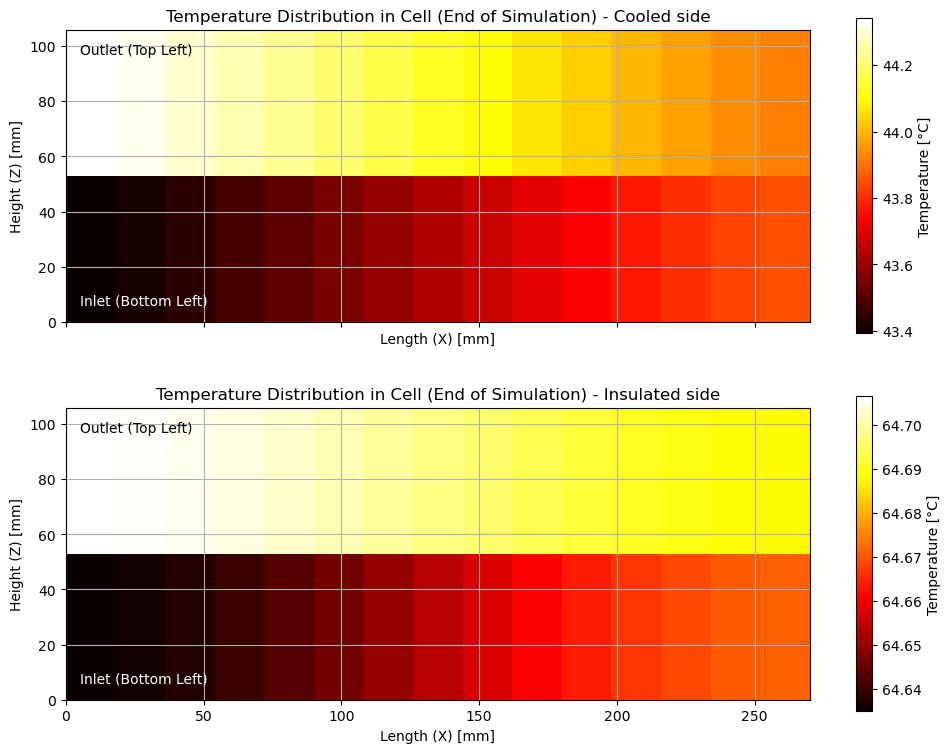

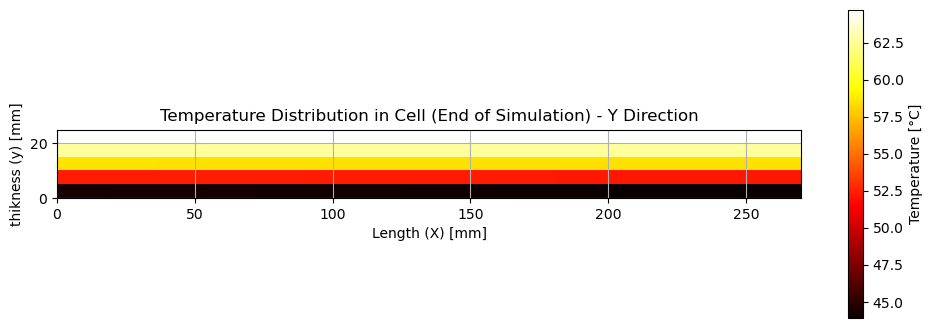

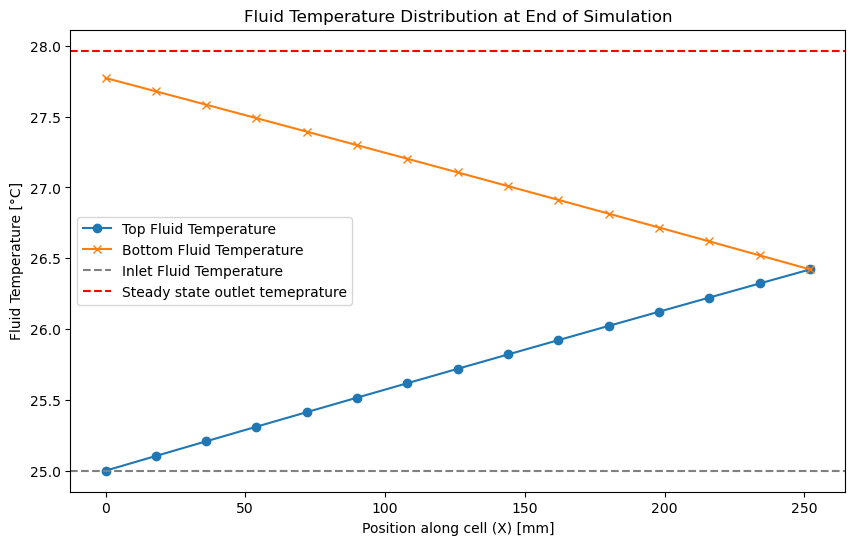

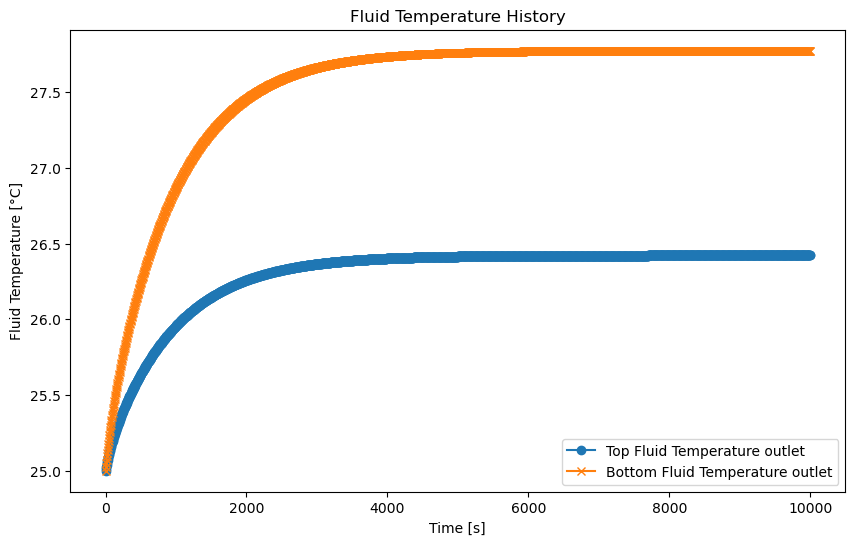

In [259]:
# --- Plot result ---
fig, ax = plt.subplots(2,1, figsize=(12, 9), sharex=True, sharey=True)
extent = [0, length*1000, 0, height*1000]
ax[0].imshow(T[:, 0, :].T, cmap="hot", origin="lower", extent=extent)
plt.colorbar(ax[0].imshow(T[:, 0, :].T, cmap="hot", origin="lower", extent=extent), ax=ax[0], label="Temperature [°C]")
ax[0].set_xlabel("Length (X) [mm]")
ax[0].set_ylabel("Height (Z) [mm]")
ax[0].set_title("Temperature Distribution in Cell (End of Simulation) - Cooled side")
ax[0].grid(True)
#annotate inlet and outlet
ax[0].text(5, 5, "Inlet (Bottom Left)", color="white", fontsize=10, ha="left", va="bottom")
ax[0].text(5, height*1000 - 5, "Outlet (Top Left)", color="black", fontsize=10, ha="left", va="top")


ax[1].imshow(T[:, 4, :].T, cmap="hot", origin="lower", extent=extent)
plt.colorbar(ax[1].imshow(T[:, 4, :].T, cmap="hot", origin="lower", extent=extent), ax=ax[1], label="Temperature [°C]")
ax[1].set_xlabel("Length (X) [mm]")
ax[1].set_ylabel("Height (Z) [mm]")
ax[1].set_title("Temperature Distribution in Cell (End of Simulation) - Insulated side")
ax[1].grid(True)
#annotate inlet and outlet
ax[1].text(5, 5, "Inlet (Bottom Left)", color="white", fontsize=10, ha="left", va="bottom")
ax[1].text(5, height*1000 - 5, "Outlet (Top Left)", color="black", fontsize=10, ha="left", va="top")



# Plot also the temperature in the y direction
plt.figure(figsize=(12, 4))
extent = [0, length*1000, 0, thickness*1000]
plt.imshow(T[:, :, 1].transpose(), cmap="hot", origin="lower", extent=tuple(extent))
plt.colorbar(label="Temperature [°C]")
plt.xlabel("Length (X) [mm]")
plt.ylabel("thikness (y) [mm]")
plt.title("Temperature Distribution in Cell (End of Simulation) - Y Direction")
plt.grid(True)


# Plot the water temperature at the end of the simulation
plt.figure(figsize=(10, 6))
plt.plot(np.arange(nx) * dx * 1000, T_fluid_z0, label="Top Fluid Temperature", marker='o')
plt.plot(np.arange(nx) * dx * 1000, T_fluid_z1, label="Bottom Fluid Temperature", marker='x')
plt.axhline(y=T_fluid_in, color='gray', linestyle='--', label="Inlet Fluid Temperature")
plt.axhline(y = T_fluid_in+Q_tot/(flow_rate * cp_fluid), color='red', linestyle='--', label="Steady state outlet temeprature")
plt.xlabel("Position along cell (X) [mm]")
plt.ylabel("Fluid Temperature [°C]")
plt.title("Fluid Temperature Distribution at End of Simulation")
plt.legend()

#Plot the fluid temperature history
plt.figure(figsize=(10, 6))
plt.plot(np.arange(nt) * dt, t_hist_fluid_z0[:, -1], label="Top Fluid Temperature outlet", marker='o')
plt.plot(np.arange(nt) * dt, t_hist_fluid_z1[:, 0], label="Bottom Fluid Temperature outlet", marker='x')
plt.xlabel("Time [s]")
plt.ylabel("Fluid Temperature [°C]")
plt.title("Fluid Temperature History")
plt.legend()
plt.show()





In [260]:
# Distribution of temperature in 
print(f"Element in x direction:{nx}")
print(f"Element in y direction:{ny}")
print(f"Element in z direction:{nz}")
T[:,4,:]

Element in x direction:15
Element in y direction:5
Element in z direction:2


array([[64.63488388, 64.70653458],
       [64.63580565, 64.7060965 ],
       [64.6375635 , 64.70526729],
       [64.6400153 , 64.70411992],
       [64.64299644, 64.7027309 ],
       [64.6463442 , 64.70116697],
       [64.64990953, 64.6994817 ],
       [64.65355928, 64.69771889],
       [64.65717249, 64.69591969],
       [64.66063373, 64.69413079],
       [64.66382602, 64.69241209],
       [64.6666253 , 64.69084203],
       [64.66889952, 64.68951792],
       [64.67051586, 64.6885479 ],
       [64.67135904, 64.68803162]])

In [261]:
#%matplotlib notebook
import matplotlib.animation as animation
animation_flag = 0  # Set to 1 to enable animation, 0 to disable
if animation_flag == 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    extent = [0, length * 1000, 0, height * 1000]  # For consistent mm scale
    im = ax.imshow(T_hist[0], cmap="hot", origin="lower", extent=extent, vmin=np.min(T_hist), vmax=np.max(T_hist))
    cbar = plt.colorbar(im, ax=ax, label="Temperature [°C]")
    ax.set_xlabel("Length (X) [mm]")
    ax.set_ylabel("Height (Z) [mm]")
    ax.set_title("Temperature Evolution in Cell")
    ax.grid(True)

    def update(frame):
        im.set_array(T_hist[frame])
        ax.set_title(f"Time: {frame*dt:.1f} s")
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=nt, interval=30, blit=True)
    ani.save("temperature_evolution.mp4", writer="ffmpeg", fps=30)

In [262]:
delta_T_check = Q_tot/(flow_rate * cp_fluid)
delta_T_sim = -T_fluid_z0[0] +T_fluid_z1[0]   # Check the temperature change at the outlet
print(f"Check on temperature change: {delta_T_sim:.2f} C")
print(f"Check on temperature change: {delta_T_check:.2f} C")



Check on temperature change: 2.77 C
Check on temperature change: 2.97 C


In [263]:
k_y = 1 # thermal conductivity in y direction [W/m·K]
R_th_y = thickness/(dx*dz*k_y) # thermal resistance in y direction [K/W]
print(f"Thermal resistance in y direction: {R_th_y:.4f} K/W")

delta_T_y = (q_gen*dV)*R_th_y
print(q_gen*dV)
display(delta_T_y)



Thermal resistance in y direction: 25.9958 K/W
0.4000000000000001


10.39832285115304

In [264]:
test = np.ones([2,3,2])

display(test)

array([[[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]]])